<a href="https://colab.research.google.com/github/laurakalniete/valodu-tehnologijas-exam/blob/main/exam_v.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paaudzes prognozēšana pēc rakstīšanas stila sociālajos tīklos

**Mērķis**: Izveidot un novērtēt teksta klasifikācijas modeļus, kas
pēc sociālo mediju ierakstiem nosaka autora paaudzi - Gen Z, Millennial, GenX, Boomer



Vecums paaudzēs:

Gen Z: **14-29**\
Millennials: **30-45**\
Gen X: **46-61**\
Boomers: **62-80**



In [ ]:
!pip install nltk
!pip install scikit-learn
!pip install seaborn
!pip install transformers datasets torch

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB

import numpy
import seaborn
import matplotlib.pyplot as mplot

In [ ]:
import pandas as pd

In [ ]:
import torch
print(torch.cuda.is_available())

Mapping uz paaudzēm no 0, 1, 2, 3, kā ir csv failos

In [ ]:
gen = ["Gen Z", "Millennial", "Gen X", "Boomer"]

#Baseline: Naive Bayes + TF IDF

train, test un validation datu nolasīšana

In [ ]:
# data frame
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
val_df = pd.read_csv("validation.csv")

In [ ]:
print(test_df.shape)
print(train_df.shape)
print(val_df.shape)

(1105, 2)
(5154, 2)
(1104, 2)


Texts un labels atdalīšana

In [ ]:
train_texts = train_df["body"].astype(str).tolist()
train_labels = train_df["gen"].tolist()

test_texts = test_df["body"].astype(str).tolist()
test_labels = test_df["gen"].tolist()

val_texts = val_df["body"].astype(str).tolist()
val_labels = val_df["gen"].tolist()

tf-idf vectorizer (https://github.com/LUMII-AILab/NLP_Course/blob/main/notebooks/tf_idf.ipynb)

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# # tfidf_vectorizer = TfidfVectorizer(stop_words=None, lowercase=False) #lowercase false, lai automatiski nepartaisa visu par mazajiem burtiem, bez stopvardiem jo drosi vien palidzes saprast starp generationiem
# # tfidf_vectorizer = TfidfVectorizer(stop_words="english", lowercase=False) #anglu teksts, stop_words="english"
# tfidf_vectorizer = TfidfVectorizer(stop_words="english", lowercase=True)
# # tfidf_vectorizer = TfidfVectorizer(stop_words=None, lowercase=True)

# train_tfidf = tfidf_vectorizer.fit_transform(train_texts) # fit transform iemacas vocab un parvers par vektoriem, parastais transform tikai vektorize
# test_tfidf = tfidf_vectorizer.transform(test_texts)
# val_tfidf = tfidf_vectorizer.transform(val_texts)

Multinomial un Complement NB labāko parametru iegūšana

https://github.com/LUMII-AILab/NLP_Course/blob/main/notebooks/NaiveBayes.ipynb

In [ ]:

# MULTINOMIAL NB
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

# COMPLEMENT NB
# pipeline = Pipeline([
#     ("tfidf", TfidfVectorizer()),
#     ("nb", ComplementNB())
# ])

# visi settingi / pirmie divi ir koda augstak
param_grid = {
    "tfidf__stop_words": [None, "english"],
    "tfidf__lowercase": [False, True],
    "tfidf__ngram_range": [(1, 1), (1, 2)], #1,2 vardu pari
    "tfidf__min_df": [1, 2, 3], #vardi kas paradas mazak par 1, 2, 3 reizem
    "nb__alpha": [0.1, 0.5, 1.0] #smoothing parametrs
}

# grid search cross validation
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(train_texts, train_labels) #automatiski notiek vektorizesana

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

val_predictions = grid.predict(val_texts)

Best params: {'nb__alpha': 0.1, 'tfidf__lowercase': True, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': None}
Best CV accuracy: 0.6181606519208381


Novērtējums

In [ ]:
akuratums = accuracy_score(val_labels, val_predictions)
print("akuratums: ", akuratums)

# print(classification_report(val_labels, val_predictions)) #  nav mapping uz gen, tikai 0, 1, 2, 3
print(classification_report(val_labels, val_predictions, labels=[0, 1, 2, 3], target_names=gen, digits=4))

akuratums:  0.6367753623188406
              precision    recall  f1-score   support

       Gen Z       0.71      0.67      0.69       260
  Millennial       0.61      0.54      0.57       284
       Gen X       0.67      0.60      0.63       288
      Boomer       0.58      0.74      0.65       272

    accuracy                           0.64      1104
   macro avg       0.64      0.64      0.64      1104
weighted avg       0.64      0.64      0.64      1104



In [ ]:
best_model = grid.best_estimator_

test_predictions = best_model.predict(test_texts) #grid.predict tapat panem labako modeli
akuratums = accuracy_score(test_labels, test_predictions)
print("akuratums: ", akuratums)
print(classification_report(test_labels, test_predictions, labels=[0, 1, 2, 3], target_names=gen, digits=4))

akuratums:  0.632579185520362
              precision    recall  f1-score   support

       Gen Z       0.67      0.68      0.68       259
  Millennial       0.67      0.59      0.63       285
       Gen X       0.62      0.52      0.57       288
      Boomer       0.59      0.74      0.66       273

    accuracy                           0.63      1105
   macro avg       0.64      0.64      0.63      1105
weighted avg       0.64      0.63      0.63      1105



Kļūdas un confusion matrica

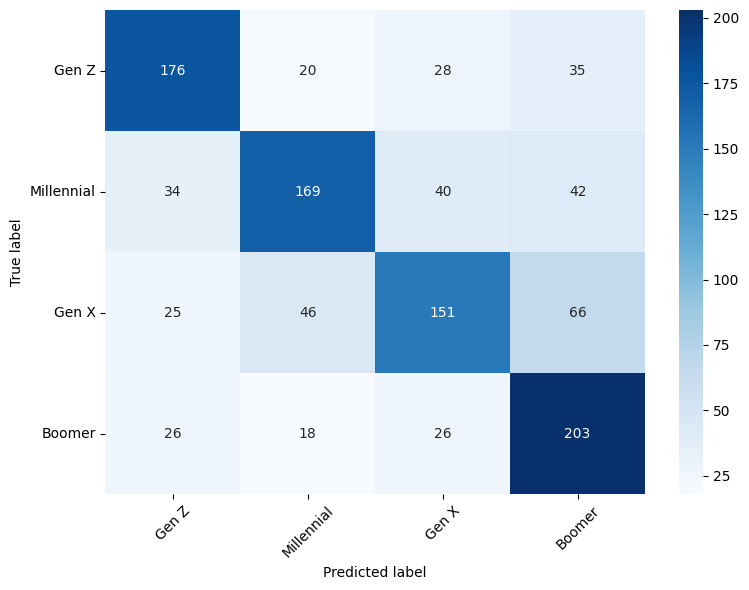

In [ ]:
errors = pd.DataFrame({
    # "text": test_texts,
    "true_label": test_labels,
    "predicted_label": test_predictions
})

errors = errors[errors["true_label"] != errors["predicted_label"]]

# print(errors.head(20))#pirmas 20 kludas
# print("Number of errors:", len(errors))


# LABELS = nb_classifier.classes_
# matrix = confusion_matrix(test_labels, test_predictions, labels=LABELS)

matrix = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2, 3])

mplot.figure(figsize=(8, 6))
seaborn.heatmap(
    matrix,
    xticklabels=gen,
    yticklabels=gen,
    annot=True,
    fmt="d",
    cmap="Blues"
)

mplot.xlabel("Predicted label")
mplot.ylabel("True label")
mplot.xticks(rotation=45)
mplot.yticks(rotation=0)
mplot.tight_layout()
mplot.show()

Lietotāja ievade

In [ ]:
def predict_input(user_txt):

    user_txt = input("Teksts vai 0(quit): ")

    # u_tfidf=tfidf_vectorizer.transform([user_txt])
    # prediction = nb_classifier.predict(u_tfidf)[0]
    prediction = grid.predict([user_txt])[0]

    print("Predicted generation: ", gen[prediction])

In [ ]:
while True:
  user_text = input("Teksts vai 0(quit): ")
  if user_text=="0": break

  predict_input(user_text)

# BERT

In [ ]:
# [transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
!pip install emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=845445f1949b24a264a457a70d061e9d1c89f6dd2be4cb4c3a88183a6e87a623
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from torch.optim import AdamW

Datu ielāde

In [ ]:
# lidzigi ka pie tf-idf, nodala tekstu un labels
def load_dataset(fname):
  df = pd.read_csv(fname, header=0)

  sentences = df.body.values
  labels = df.gen.values
  return sentences, labels

train_sentences, train_labels = load_dataset("train.csv")
val_sentences, val_labels = load_dataset("validation.csv")
test_sentences, test_labels = load_dataset("test.csv")




In [ ]:
# ielade bertweet (large vai base) tokenizeri

# tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-large")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenu pārbaude (lai varētu noteikt max_len)

In [ ]:
# parbauda tokenu garumus (lai varetu talak izveleties max_len)
lengths = [len(tokenizer.tokenize(s)) for s in train_sentences] # sadala tekstu (rindinas) tokenos, katram saglaba garumu
print(f"Max: {max(lengths)}, Mean: {numpy.mean(lengths):.0f}, 95th percentile: {numpy.percentile(lengths, 95):.0f}")

Max: 814, Mean: 40, 95th percentile: 126


Tekstu tokenizēšana

In [ ]:
# funkcija preprocess_data pārvērš "sentences" formātā, kādu sagaida bert modelis
def preprocess_data(sentences, labels, max_len=128): # lielaka dala ierakstu train datu kopā ir zem 126 tokeniem
    input_ids = []
    attention_masks = []

    for sent in sentences:
        encoded_dict = tokenizer(
            sent,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True, # nošķir īstos tokenus no padding
            return_tensors='pt', #pytorch tensors
        )

        input_ids.append(encoded_dict['input_ids']) #tokenizetais "sentence"
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(input_ids, attention_masks, labels)

# preprocess_data visam datu kopam, lai iegutu TensorDataset katrai
train_data = preprocess_data(train_sentences, train_labels)
val_data = preprocess_data(val_sentences, val_labels)
test_data = preprocess_data(test_sentences, test_labels)

Bert modelis

In [ ]:
# ielade pasu bertweet (base un large) modeli

# model = AutoModelForSequenceClassification.from_pretrained("vinai/bertweet-base", num_labels=4)
model = AutoModelForSequenceClassification.from_pretrained("vinai/bertweet-large", num_labels=4)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) #parvieto modeli uz gpu (T4)
print("Using device:", device)

optimizer = AdamW(model.parameters(), lr=1e-5, eps=1e-8)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [ ]:
#dataloaderi nodrosina datu padošanu modelim pa daļām - batch size
train_dataloader = DataLoader(train_data, sampler=RandomSampler(train_data), batch_size=32)
val_dataloader = DataLoader(val_data, sampler=SequentialSampler(val_data), batch_size=32)
test_dataloader = DataLoader(test_data, sampler=SequentialSampler(test_data), batch_size=32)

Training

In [ ]:
best_val_accuracy = 0

for epoch in range(5):
    print(f'Epoch {epoch + 1}/5')

    # trenesana
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_dataloader):
        b_input_ids, b_input_mask, b_labels = batch # iegust input_ids, masku un labels no dataloadera (train)
        b_input_ids = b_input_ids.to(device)
        b_input_mask = b_input_mask.to(device)
        b_labels = b_labels.to(device)

        optimizer.zero_grad() # atjaunina gradient no iepriekseja batch
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels) # iegust predictions. padodot labels, tiek automatiski aprekinats loss

        loss = outputs.loss
        total_train_loss += loss.item() #pievieno batch loss kopejam loss
        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f'Average training loss: {avg_train_loss:.2f}')

    # valiācija
    model.eval() # parsledz bert uz evaluation mode
    total_val_accuracy = 0
    total_val_loss = 0
    total_examples = 0

    for batch in val_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        # skip gradientu rekinasanu, jo evaluation rezima netiek atjauninati weights
        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        total_val_loss += loss.item()

        logits = outputs.logits.detach().cpu().numpy() # parvers par numpy array
        label_ids = b_labels.to('cpu').numpy()
        predictions = numpy.argmax(logits, axis=1)
        total_val_accuracy += numpy.sum(predictions == label_ids) #izskaita, cik predictions ir pareizi
        total_examples += len(label_ids)

    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_accuracy = total_val_accuracy / total_examples
    print(f'Validation loss: {avg_val_loss:.2f}')
    print(f'Validation accuracy: {avg_val_accuracy:.2f}')

    # saglaba labako modeli ar augstako accuracy
    if avg_val_accuracy > best_val_accuracy:
        best_val_accuracy = avg_val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'✓ Best model saved (val accuracy: {avg_val_accuracy:.2f})')
    else:
        print(f'✗ No improvement (best so far: {best_val_accuracy:.2f})')

print('Training complete')

Epoch 1/10
Average training loss: 1.20
Validation loss: 0.88
Validation accuracy: 0.64
✓ Best model saved (val accuracy: 0.64)
Epoch 2/10
Average training loss: 0.80
Validation loss: 0.82
Validation accuracy: 0.68
✓ Best model saved (val accuracy: 0.68)
Epoch 3/10
Average training loss: 0.61
Validation loss: 0.76
Validation accuracy: 0.71
✓ Best model saved (val accuracy: 0.71)
Epoch 4/10
Average training loss: 0.43
Validation loss: 0.80
Validation accuracy: 0.72
✓ Best model saved (val accuracy: 0.72)
Epoch 5/10
Average training loss: 0.27
Validation loss: 0.89
Validation accuracy: 0.72
✓ Best model saved (val accuracy: 0.72)
Epoch 6/10
Average training loss: 0.19
Validation loss: 1.04
Validation accuracy: 0.71
✗ No improvement (best so far: 0.72)
Epoch 7/10
Average training loss: 0.14
Validation loss: 1.15
Validation accuracy: 0.71
✗ No improvement (best so far: 0.72)
Epoch 8/10
Average training loss: 0.10
Validation loss: 1.14
Validation accuracy: 0.72
✗ No improvement (best so far:

test eval

In [ ]:
# ielādē labāko modeli
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

total_test_accuracy = 0
total_examples = 0
all_predictions = []
all_labels = []

#gandriz identiski eval kodam
for batch in test_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

    logits = outputs.logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    predictions = numpy.argmax(logits, axis=1)

    # saglabā visus rezultātus un label_ids
    all_predictions.extend(predictions)
    all_labels.extend(label_ids)

akuratums = accuracy_score(all_labels, all_predictions)
print("akuratums: ", akuratums)

print(classification_report(all_labels, all_predictions, labels=[0,1,2,3], target_names=gen, digits=4))

akuratums:  0.7493212669683258
              precision    recall  f1-score   support

       Gen Z     0.7329    0.8263    0.7768       259
  Millennial     0.6824    0.7614    0.7197       285
       Gen X     0.7824    0.6493    0.7097       288
      Boomer     0.8203    0.7692    0.7940       273

    accuracy                         0.7493      1105
   macro avg     0.7545    0.7515    0.7500      1105
weighted avg     0.7544    0.7493    0.7488      1105



Saglabāšana

In [ ]:
model.save_pretrained('./bertweet_model')
tokenizer.save_pretrained('./bertweet_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bertweet_model/tokenizer_config.json', './bertweet_model/tokenizer.json')

Confusion matrica BERT modelim

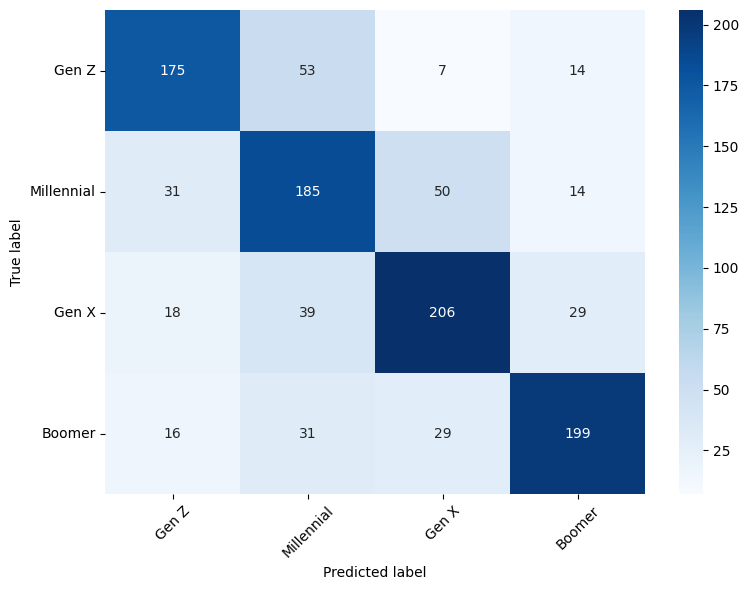

In [ ]:
# errors = pd.DataFrame({
#     "true_label": all_labels,
#     "predicted_label": all_predictions
# })

# errors = errors[errors["true_label"] != errors["predicted_label"]]
# print(errors.head(20))#pirmas 20 kludas
# print("Number of errors:", len(errors))


matrix = confusion_matrix(all_labels, all_predictions, labels=[0, 1, 2, 3])

mplot.figure(figsize=(8, 6))
seaborn.heatmap(
    matrix,
    xticklabels=gen,
    yticklabels=gen,
    annot=True,
    fmt="d",
    cmap="Blues"
)

mplot.xlabel("Predicted label")
mplot.ylabel("True label")
mplot.xticks(rotation=45)
mplot.yticks(rotation=0)
mplot.tight_layout()
mplot.show()

cleanup (no praktisko darbu koda)

In [ ]:
# Delete large objects
del model
del optimizer

# Run Python garbage collection
import gc
gc.collect()

# Release cached GPU memory back to CUDA allocator
torch.cuda.empty_cache()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "./bertweet_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()